# Comparing t-SNE and UMAP Dimension Reduction Models

## Import required libraries

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import umap.umap_ as UMAP
from sklearn.datasets import make_blobs
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

%matplotlib inline

## Generate synthetic data with four clusters in a 3D space

In [2]:
centers = [
    [2, -6, -6],
    [-1, 9, 4],
    [-8, 7, 2],
    [4, 7, 9]
]
cluster_std = [1, 1, 2, 3.5]

blobs: tuple[np.ndarray, np.ndarray] = make_blobs(n_samples=500, centers=centers, n_features=3, cluster_std=cluster_std, random_state=42)
X, labels_ = blobs

## Display the data in an interactive `Plotly` 3D scatter plot

In [3]:
df = pd.DataFrame(X, columns=["X", "Y", "Z"])

fig = px.scatter_3d(df, x="X", y="Y", z="Z", color=labels_.astype(str), opacity=0.7, color_discrete_sequence=px.colors.qualitative.G10, title="3D Scatter Plot of Four Blobs")
fig.update_traces(marker={"size": 5, "line": {"width": 1, "color": "black"}}, showlegend=False)
fig.update_layout(coloraxis_showscale=False, width=1000, height=800)

## Interact with the plot

<p>Go ahead and click on the icons at the top right of the plot to select zoom, rotate, and pan modes. Then use your mouse to interact with the plot. This is a great way to inspect 3D data as it's difficult to learn much from a static 3D plot.</p>

<p>Some observation about the four blobs:</p>
<ul>
    <li>The blobs have varying densities.</li>
    <li>One blob is distinct from the others.</li>
    <li>The two largest blobs are distinct from each other, but both have a bit of overlap with the other blob between them.</li>
</ul>

### Exercise

<p>Standardize the data to prepare it for the three projection methods.</p>

In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Apply t-SNE to reduce the dimensionality to 2D

<p>You'll set the perplexity to the default value of 30 here. The results vary quite a bit if you change the perplexity, so go ahead and experiment.</p>

In [5]:
tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
X_tsne = tsne.fit_transform(X_scaled)

## Let's plot the 2D t-SNE result

[]

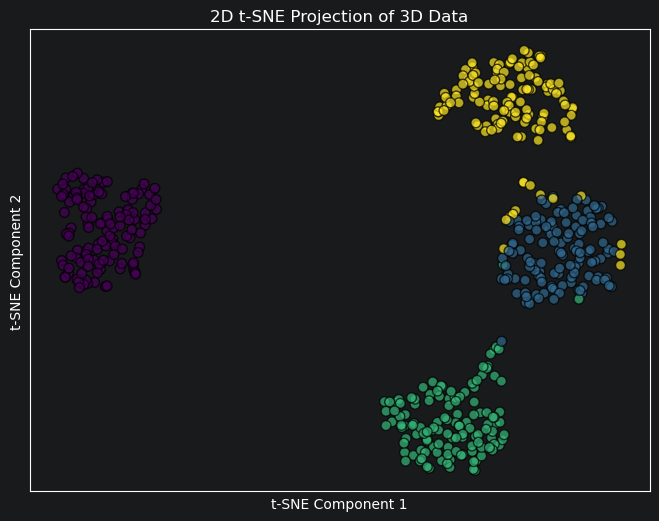

In [6]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(1, 1, 1)
ax.scatter(X_tsne[:, 0], X_tsne[:, 1], c=labels_, cmap="viridis", s=50, alpha=0.7, edgecolor="k")
ax.set_title("2D t-SNE Projection of 3D Data")
ax.set_xlabel("t-SNE Component 1")
ax.set_ylabel("t-SNE Component 2")
ax.set_xticks([])
ax.set_yticks([])

<p>Some observation about this t-SNE result:</p>
<ul>
    <li>t-SNE projected the data into four distinct clusters, although the original data had some overlap between a few clusters.</li>
    <li>You can see that some of the points ended up in the <b>wrong</b> cluster, although to be fair, t-SNE has no knowledge of which clusters the points actually belong to.</li>
    <li>All the clusters have similar densities.</li>
    <li>Two of the blobs are distinct from each other but <b>gave up</b> some of their points to the blob they originally had overlapped with.</li>
    <li>A <b>perfect</b> result would not completely separate the overlaps between blobs.</li>
    <li>Notice that the distance between the blobs is consistent with the degree to which they were originally separated.</li>
</ul>

## Compare UMAP and PCA dimensionality reduction to two dimensions

[]

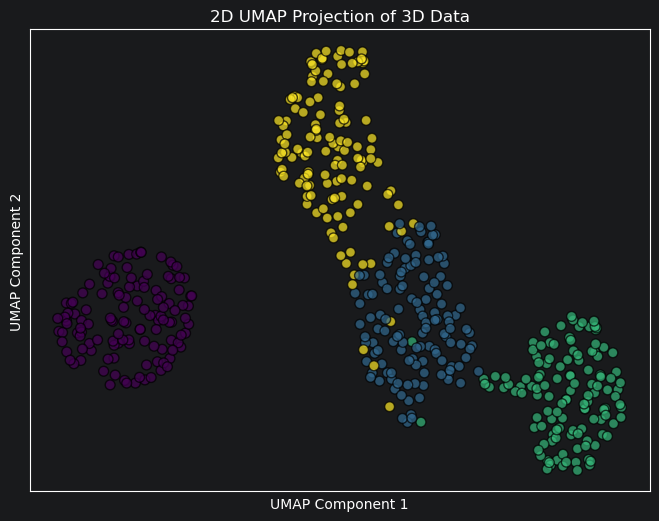

In [7]:
umap_model = UMAP.UMAP(n_components=2, random_state=42, min_dist=0.5, spread=1, n_jobs=1)
X_umap = umap_model.fit_transform(X_scaled)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(1, 1, 1)
ax.scatter(X_umap[:, 0], X_umap[:, 1], c=labels_, cmap="viridis", s=50, alpha=0.7, edgecolor="k")
ax.set_title("2D UMAP Projection of 3D Data")
ax.set_xlabel("UMAP Component 1")
ax.set_ylabel("UMAP Component 2")
ax.set_xticks([])
ax.set_yticks([])

<p>Some observation about this UMAP result:</p>
<ul>
    <li>UMAP currectly projected the data into four partially distinct clusters, with one cluster completely distinct from the others.</li>
    <li>Unlike t-SNE, it has preserved the connectedness that the original data had with the partially overlapping clusters.</li>
    <li>You can see that, like t-SNE, some of the points ended up in the <b>wrong</b> cluster.</li>
    <li>Again, like t-SNE, all the clusters have similar densities.</li>
    <li>A <b>perfect</b> result would not completely separate the overlaps between blobs, because they actually do overlap in the original feature space.</li>
    <li>The distance between the clusters is again consistent with the degree to which they were originally separated.</li>
</ul>

[]

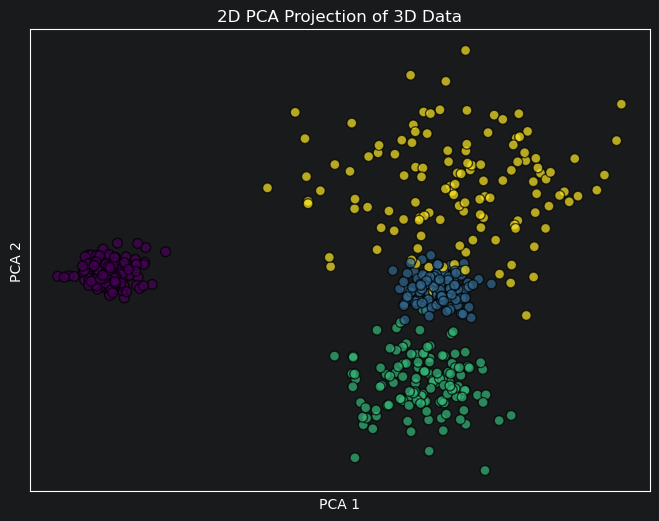

In [8]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

fig = plt.figure(figsize=(8, 6))
ax2 = fig.add_subplot(1, 1, 1)
ax2.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_, cmap="viridis", s=50, alpha=0.7, edgecolor="k")
ax2.set_title("2D PCA Projection of 3D Data")
ax2.set_xlabel("PCA 1")
ax2.set_ylabel("PCA 2")
ax2.set_xticks([])
ax2.set_yticks([])

<p>Some observation about this PCA result:</p>
<ul>
    <li>PCA faithfully preserved the relative blob densities.</li>
    <li>PCA also preserved the relative separation between blobs.</li>
    <li>The distance between the clusters is very consistent with the degree to which they were originally separated.</li>
    <li>PCA and t-SNE took very little time to complete compared to UMAP.</li>
    <li>IMNSHO, PCA outperformed both t-SNE and UMAP in this experiment. This points to a common tendency to want to implement more advanced algorithms. The default result is not always an improvement over the simpler established methods.</li>
</ul>

****
This is the end of the file.
****